# RAW to TIF converter

Set the input `.raw` path, the output `.tif` path, and an existing reference `.tif` path. The notebook reads the volume dimensions from the RAW filename, saves the TIFF, then compares the created TIFF against the reference TIFF.

## 1. Settings

In [13]:
from pathlib import Path

# Change these paths for each test.
RAW_PATH = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448.raw")
TIF_PATH = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448_TEST.tif")
REFERENCE_TIF_PATH = Path(r"/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448.tif")

# Dimensions are inferred from RAW_PATH as widthxheightxdepth.
# Example: sample_300x295x448.raw -> shape (448, 295, 300) in z, y, x order.
RAW_DTYPE = "uint8"

# Usually little-endian for microscope / CT exports. Use "big" if your source says so.
BYTE_ORDER = "little"

# Keep True for large volumes so the RAW file is not fully loaded before writing.
USE_MEMMAP = True

## 2. Helper functions

In [14]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile


DIMENSIONS_PATTERN = re.compile(r"(?<!\d)(\d+)\s*x\s*(\d+)\s*x\s*(\d+)(?!\d)", re.IGNORECASE)


def infer_shape_zyx_from_filename(path):
    matches = DIMENSIONS_PATTERN.findall(Path(path).stem)
    if not matches:
        raise ValueError(
            "Could not infer dimensions from the RAW filename. "
            "The filename must contain widthxheightxdepth, "
            "for example sample_300x295x448.raw or sample_ascan300x295x448.raw."
        )

    width, height, depth = (int(value) for value in matches[-1])
    return (depth, height, width)


def dtype_with_byte_order(dtype, byte_order):
    dtype = np.dtype(dtype)
    if dtype.itemsize == 1:
        return dtype

    byte_orders = {
        "little": "<",
        "big": ">",
        "native": "=",
    }
    if byte_order not in byte_orders:
        raise ValueError('BYTE_ORDER must be "little", "big", or "native".')

    return dtype.newbyteorder(byte_orders[byte_order])


def read_raw_volume(raw_path, shape_zyx, dtype, byte_order="little", use_memmap=True):
    raw_path = Path(raw_path)
    if not raw_path.is_file():
        raise FileNotFoundError(raw_path)

    dtype = dtype_with_byte_order(dtype, byte_order)
    expected_bytes = int(np.prod(shape_zyx)) * dtype.itemsize
    actual_bytes = raw_path.stat().st_size

    if actual_bytes != expected_bytes:
        raise ValueError(
            f"File size does not match the requested shape and dtype.\n"
            f"Expected: {expected_bytes:,} bytes for shape {shape_zyx} and dtype {dtype}.\n"
            f"Actual:   {actual_bytes:,} bytes."
        )

    if use_memmap:
        return np.memmap(raw_path, mode="r", dtype=dtype, shape=shape_zyx)

    return np.fromfile(raw_path, dtype=dtype).reshape(shape_zyx)


def save_tif_volume(output_path, volume):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    tifffile.imwrite(
        output_path,
        volume,
        bigtiff=True,
        photometric="minisblack",
        metadata={"axes": "ZYX"},
    )
    return output_path


def verify_created_tif_against_reference(created_path, reference_path):
    created = tifffile.imread(created_path)
    reference = tifffile.imread(reference_path)

    assert created.shape == reference.shape, f"Shape mismatch: {created.shape} != {reference.shape}"
    assert created.dtype == reference.dtype, f"Dtype mismatch: {created.dtype} != {reference.dtype}"

    if not np.array_equal(created, reference):
        difference = created.astype(np.float64) - reference.astype(np.float64)
        mismatch_count = np.count_nonzero(difference)
        raise AssertionError(
            "Data mismatch between created TIFF and reference TIFF.\n"
            f"Different voxels: {mismatch_count:,}\n"
            f"Difference range: {difference.min()} to {difference.max()}"
        )

    return created, reference

## 3. Load and preview

RAW:    /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448.raw
Output: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448_TEST.tif
Reference TIF: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448.tif
Shape:  (448, 295, 300) (z, y, x)
Dtype:  uint8
Middle slice 224: min=0, max=145


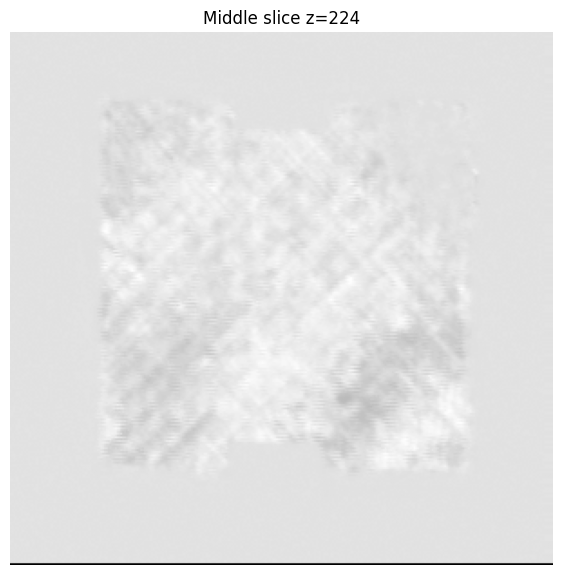

In [15]:
raw_path = Path(RAW_PATH)
tif_path = Path(TIF_PATH)
reference_tif_path = Path(REFERENCE_TIF_PATH)

shape_zyx = infer_shape_zyx_from_filename(raw_path)
dtype = np.dtype(RAW_DTYPE)
volume = read_raw_volume(raw_path, shape_zyx, dtype, BYTE_ORDER, USE_MEMMAP)

middle_z = volume.shape[0] // 2
middle_slice = np.asarray(volume[middle_z])

print(f"RAW:    {raw_path}")
print(f"Output: {tif_path}")
print(f"Reference TIF: {reference_tif_path}")
print(f"Shape:  {volume.shape} (z, y, x)")
print(f"Dtype:  {volume.dtype}")
print(f"Middle slice {middle_z}: min={middle_slice.min()}, max={middle_slice.max()}")

plt.figure(figsize=(7, 7))
plt.imshow(middle_slice, cmap="gray")
plt.title(f"Middle slice z={middle_z}")
plt.axis("off");

## 4. Save as TIF

In [16]:
saved_path = save_tif_volume(tif_path, volume)
print(f"Saved TIF volume to: {saved_path}")

Saved TIF volume to: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448_TEST.tif


## 5. Conversion check

In [17]:
created, reference = verify_created_tif_against_reference(saved_path, reference_tif_path)

print("Conversion check passed.")
print(f"Created TIF:   {saved_path}")
print(f"Reference TIF: {reference_tif_path}")
print(f"Shape: {created.shape}")
print(f"Dtype: {created.dtype}")

Conversion check passed.
Created TIF:   /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448_TEST.tif
Reference TIF: /home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/03_UT_data/Fabricacion Nacho/medidas/Na_01/10mm-range/Panel_1_77mmdistance_20mms_10mmrange_11db_ascan300x295x448.tif
Shape: (448, 295, 300)
Dtype: uint8
